# Verification of simulation subpackage: Class to compute parameter limits (QualityRequirements)

In [ ]:
# Import necessary libraries
from metpyx.sim import QualitySensitivity
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

What the class should do:
- Compute the deviation in mean air-kerma-to-dose conversion coefficient for the deviations provided
- Check linearity of the deviation in mean conversion coefficient with respect to the deviation in tube voltage
- Linear fit of the deviation in mean conversion coefficient vs deviation in tube voltage
- Calculate the tube voltage deviation limits for a given deviation in mean conversion coefficient (e.g., 2%)

Reference case for verification:
- N60 radiation quality.
- Anode angle of 20º.
- H*(10) operational quantity at 0º irradiation angle.
- mass energy transfer coefficients for air from PENELOPE 2018.
- air kerma to dose conversion coefficients from CMI 2025.
- measurement distance at 1 m.
- air thickness equal to distance.
- Deviation of (-5%, 0%, +5%) in tube voltage

## Reference case: Calculation using the QualitySensitivity class

In [3]:
# Define tube voltage deviations in percentage
tube_voltage_deviations = [-5, 0, 5]

/home/u6406/PycharmProjects/metpyx/src/metpyx/sim/spectrum.py:103: UserWarning: Zeros found in h_k values; removed for interpolation.
  warnings.warn("Zeros found in h_k values; removed for interpolation.")
/home/u6406/PycharmProjects/metpyx/src/metpyx/sim/spectrum.py:120: UserWarning: NaN values found in interpolated h_k.
  warnings.warn("NaN values found in interpolated h_k.")


In [4]:
# Compute the deviation in mean air-kerma-to-dose conversion coefficient for the deviations provided
hk_mean_deviations = []
for dev in tube_voltage_deviations:
    q = QualitySensitivity("N60", 'tube_voltage', dev, th=20)
    hk_mean_deviations.append(q.get_hk_mean_dev('h_star_10', 0)[2])

y = 0.324963 x + -0.0779649
Slope = 0.324963 ± 0.0135039 (4.155527491739227%) (1σ)
Intercept = -0.0779649 ± 0.0551295 (-70.71067811865474%) (1σ)
95% CI for slope = [0.153379, 0.496546]
95% CI for intercept = [-0.778451, 0.622522]
Slope p-value = 0.02644, intercept p-value = 0.3918
R² = 0.9983


In [5]:
# Linear fit of the deviation in mean conversion coefficient vs deviation in tube voltage

# Define the independent and dependent variables
x = np.asarray(tube_voltage_deviations)
y = np.asarray(hk_mean_deviations)

# Perform linear regression
X = sm.add_constant(x) # adds intercept term
model = sm.OLS(y, X) # ordinary least squares regression
res = model.fit() # fit the model

# Extract parameters, standard errors, and confidence intervals
intercept, slope = res.params # intercept is the constant term, slope is the coefficient for x
intercept_se, slope_se = res.bse # standard errors of the parameters
intercept_ci, slope_ci = res.conf_int(alpha=0.05) # 95% confidence intervals for the parameters
r_squared = res.rsquared # R-squared value
intercept_p_values, slope_p_values = res.pvalues # p-values for the parameters

# Print results
print(f"y = {slope:.6g} x + {intercept:.6g}")
print(f"Slope = {slope:.6g} ± {slope_se:.6g} ({slope_se/slope*100}%) (1σ)")
print(f"Intercept = {intercept:.6g} ± {intercept_se:.6g} ({intercept_se/intercept*100}%) (1σ)")
print(f"95% CI for slope = [{slope_ci[0]:.6g}, {slope_ci[1]:.6g}]")
print(f"95% CI for intercept = [{intercept_ci[0]:.6g}, {intercept_ci[1]:.6g}]")
print(f"Slope p-value = {slope_p_values:.4g}, intercept p-value = {intercept_p_values:.4g}")
print(f"R² = {r_squared:.4f}")

Linear model plausible: True
Linearity criteria: slope p-value < 0.05 and R² > 0.7
Note: With only 3 data points, statistical tests may not be reliable. Consider this when interpreting results.


In [6]:
# Simple decision rule for linearity: slope p-value < 0.05 and R² > 0.7

# Why only the slope p-value? Because we are interested in whether the slope is significantly different from zero, which indicates a linear relationship between the independent and dependent variables. The intercept p-value is less relevant for assessing linearity in this context, as it does not directly inform us about the relationship between x and y.
# Why slope p-value < 0.05? Because it indicates that there is a statistically significant linear relationship between the tube voltage deviation and the mean conversion coefficient deviation. If the slope p-value is greater than 0.05, we would fail to reject the null hypothesis that the slope is zero, suggesting that there may not be a linear relationship.
# What is the slope p-value? It is the probability of observing a slope as extreme as the one calculated from the data, assuming that the true slope is zero (no relationship). A low p-value indicates that such an extreme slope would be unlikely if there were no relationship, thus providing evidence for a linear relationship.
# What does a slope p-value < 0.05 mean? It means that there is less than a 5% chance of observing the calculated slope (or one more extreme) if the true slope were zero. This is commonly used as a threshold for statistical significance, suggesting that we have evidence to reject the null hypothesis of no relationship and accept the alternative hypothesis of a linear relationship.

# Why we check R²? Because it gives us an indication of how well the linear model explains the variability in the data. A high R² value (close to 1) suggests that the model fits the data well, while a low R² value indicates that the model does not capture much of the variability, which may suggest that a linear model is not appropriate.
# What does R² represent? It represents the proportion of the variance in the dependent variable (mean conversion coefficient deviation) that is predictable from the independent variable (tube voltage deviation). An R² of 0.7 means that 70% of the variance in the dependent variable can be explained by the linear model, which is generally considered a good fit.
# Which are good thresholds for R²? There is no strict threshold for R², as it can depend on the context and the field of study. However, a common rule of thumb is that an R² value above 0.7 indicates a strong linear relationship, while values below 0.3 may indicate a weak relationship. Values between 0.3 and 0.7 are often considered moderate.
# What other thresholds could be used for R²? Depending on the context, you might choose a more lenient threshold (e.g., 0.5) if you are working with complex data where a perfect linear fit is unlikely, or a more stringent threshold (e.g., 0.9) if you require a very strong linear relationship for your analysis.

# Evaluate linearity based on the decision rule
accept_linear = (slope_p_values < 0.05) and (r_squared > 0.7)

# Print the decision and criteria
print("Linear model plausible:", accept_linear)
print("Linearity criteria: slope p-value < 0.05 and R² > 0.7")

# Warning about small sample size
if len(y) and len(x) <= 3:
    print("Note: With only 3 data points, statistical tests may not be reliable. Consider this when interpreting results.")

Intercept not significantly different from zero: False
Intercept criteria:
Statistical: intercept p-value > 0.05 and confidence interval includes zero
Practical: relative difference below 1%


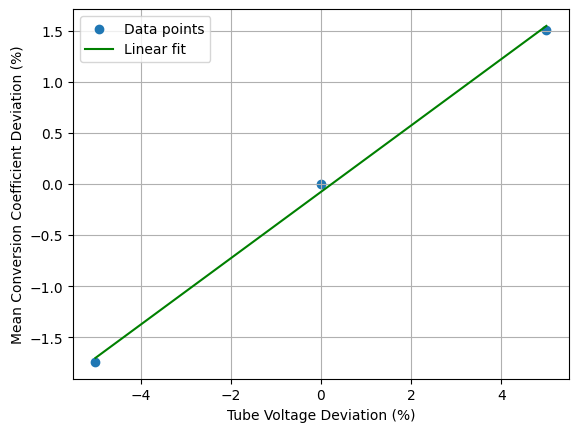

In [7]:
# Simple decision rule to check that the intercept is not significantly different from zero
# Statistically: intercept p-value > 0.05, and that the confidence interval for the intercept includes zero.
# Practically: relative difference below 1%.

# Statistical test: intercept p-value > 0.05 and confidence interval includes zero
statistical = (intercept_p_values > 0.05) and (intercept_ci[0] < 0 < intercept_ci[1])

# Practical test: check that the fitted intercept is negligibly small in absolute terms
# We use an absolute tolerance (atol) expressed in the same units as `intercept`.
# In this notebook `intercept` and `hk_mean_deviations` are expressed in percent (percentage points),
# so `atol = 1` means "allow the intercept to differ from zero by up to 1 percentage point"
# (i.e. intercept in the interval [-1, +1]).
# This is an absolute check (not relative): np.isclose(intercept, 0, atol=atol) tests
# whether abs(intercept - 0) <= atol.
atol = 1
# Use np.isclose to check if the intercept is close to zero within the absolute tolerance
practical = np.isclose(intercept, 0, atol=atol)

# Accept that the intercept is not significantly different from zero if both statistical and practical criteria are met
accept_intercept_zero = statistical and practical

# Print the decision and criteria
print("Intercept not significantly different from zero:", accept_intercept_zero)
print("Intercept criteria:")
print("Statistical: intercept p-value > 0.05 and confidence interval includes zero")
print("Practical: absolute difference below 1 percentage point")

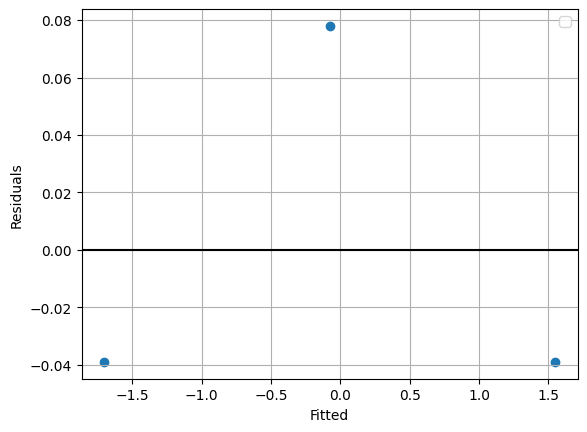

In [8]:
# Plotting the data points and the linear fit
xs = np.linspace(x.min(), x.max(), 100)
ys = intercept + slope * xs

plt.figure()
plt.scatter(x, y, label='Data points')
plt.plot(xs, ys, color="green", label='Linear fit')
plt.xlabel('Tube Voltage Deviation (%)')
plt.ylabel('Mean Conversion Coefficient Deviation (%)')
plt.legend()
plt.grid()
plt.show()

In [9]:
# Plotting the residuals of the linear fit

# What should we look for in the residuals plot? We should look for randomness in the distribution of residuals around zero, which would indicate that the linear model is appropriate. If we see patterns (e.g., a funnel shape, curvature, or systematic deviations), it may suggest that the linear model is not a good fit for the data.

fitted = res.fittedvalues
resid = res.resid

plt.figure()
plt.scatter(fitted, resid)
plt.axhline(0, color="k")
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.legend()
plt.grid()
plt.show()

Tube voltage deviation limit for a 2% deviation in mean conversion coefficient: 6.39%


In [ ]:
# Calculate the tube voltage deviation limits for a given deviation in mean conversion coefficient (e.g., 2%)

# Define target deviation in mean conversion coefficient (percentage)
target_deviation = 2

# Use the linear fit to calculate the tube voltage deviation that corresponds to the target deviation in mean conversion coefficient
tube_voltage_deviation_limit = (target_deviation - intercept) / slope

print(f"Tube voltage deviation limit for a {target_deviation}% deviation in mean conversion coefficient: {tube_voltage_deviation_limit:.2f}%")